# Module 3 — Revenue at Risk & Campaign ROI
## Goal: Convert churn predictions into business impact numbers
## Formula: Revenue at Risk = CLV × Churn Probability
## Output: revenue_at_risk.csv — feeds directly into Power BI

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../outputs/risk_scored_customers.csv')

print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded: (7032, 12)
Columns: ['customerID', 'Churn_Probability', 'Risk_Label', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Segment', 'CLV_Enhanced', 'CLV_Tier', 'Churn', 'Priority', 'Retention_Strategy']


,customerID,Churn_Probability,Risk_Label,tenure,MonthlyCharges,TotalCharges,Segment,CLV_Enhanced,CLV_Tier,Churn,Priority,Retention_Strategy
0,7590-VHVEG,0.8734,High Risk,1,29.85,29.85,Inactive,7.46,Low Value,No,High,Email Campaign
1,5575-GNVDE,0.0838,Low Risk,34,56.95,1889.50,At Risk,1102.21,High Value,No,Low,No Action Needed
2,3668-QPYBK,0.6258,Medium Risk,2,53.85,108.15,Inactive,45.06,Low Value,Yes,Medium,SMS Reminder
3,7795-CFOCW,0.0674,Low Risk,45,42.30,1840.75,At Risk,1073.77,High Value,No,Low,No Action Needed
4,9237-HQITU,0.8359,High Risk,2,70.70,151.65,Inactive,63.19,Low Value,Yes,High,Email Campaign


In [10]:
# Revenue at Risk = CLV × Churn Probability
# This tells us: how much revenue are we expected to lose from each customer

df['Revenue_at_Risk'] = (df['CLV_Enhanced'] * df['Churn_Probability']).round(2)

print("Revenue at Risk Summary:")
print(df['Revenue_at_Risk'].describe().round(2))

print(f"\nTotal Revenue at Risk: ${df['Revenue_at_Risk'].sum():,.2f}")
print(f"Average Revenue at Risk per customer: ${df['Revenue_at_Risk'].mean():,.2f}")

Revenue at Risk Summary:
count    7032.00
mean      552.65
std       860.11
min         0.14
25%        28.56
50%       162.87
75%       685.06
max      5999.58
Name: Revenue_at_Risk, dtype: float64

Total Revenue at Risk: $3,886,229.33
Average Revenue at Risk per customer: $552.65


Revenue at Risk by Segment

Revenue at Risk by Segment:
                 Total Revenue at Risk  Avg Revenue at Risk  Customers
Segment                                                               
Champions                   2701319.88              1376.82       1962
Loyal Customers              803049.90               590.04       1361
At Risk                      322975.38               178.64       1808
Inactive                      58884.17                30.98       1901


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20768\478559022.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rev_by_segment.index,


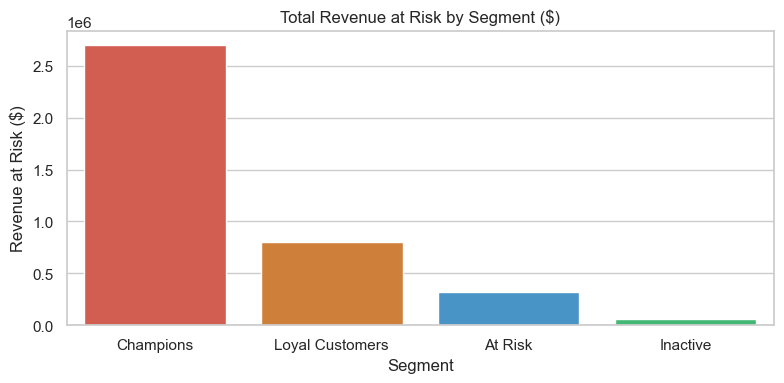

In [11]:
rev_by_segment = df.groupby('Segment')['Revenue_at_Risk'].agg(['sum','mean','count'])
rev_by_segment.columns = ['Total Revenue at Risk','Avg Revenue at Risk','Customers']
rev_by_segment = rev_by_segment.sort_values('Total Revenue at Risk', ascending=False)

print("Revenue at Risk by Segment:")
print(rev_by_segment.round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=rev_by_segment.index, 
            y=rev_by_segment['Total Revenue at Risk'],
            palette=['#e74c3c','#e67e22','#3498db','#2ecc71'])
plt.title('Total Revenue at Risk by Segment ($)')
plt.xlabel('Segment')
plt.ylabel('Revenue at Risk ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/shap_plots/revenue_at_risk_by_segment.png',
            dpi=150, bbox_inches='tight')
plt.show()

Revenue at Risk by Priority:
          Total Revenue at Risk  Avg Revenue at Risk  Customers
Priority                                                       
Critical              795622.22              1718.41        463
High                 1816312.00               853.93       2127
Medium                 76367.07               112.80        677
Low                  1197928.04               318.17       3765


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20768\3239816681.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rev_by_priority.index,


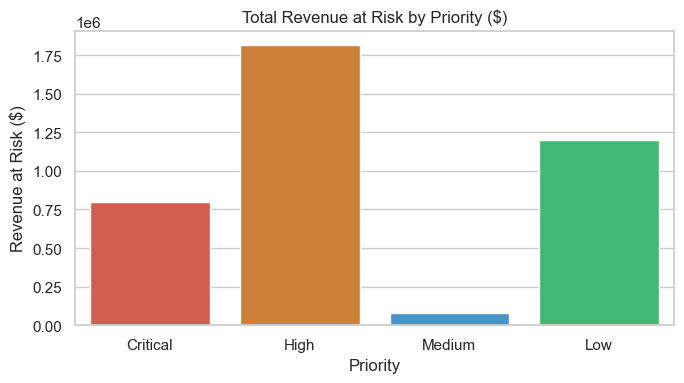

In [12]:
rev_by_priority = df.groupby('Priority')['Revenue_at_Risk'].agg(['sum','mean','count'])
rev_by_priority.columns = ['Total Revenue at Risk','Avg Revenue at Risk','Customers']
rev_by_priority = rev_by_priority.reindex(['Critical','High','Medium','Low'])

print("Revenue at Risk by Priority:")
print(rev_by_priority.round(2))

plt.figure(figsize=(7,4))
colors = ['#e74c3c','#e67e22','#3498db','#2ecc71']
sns.barplot(x=rev_by_priority.index,
            y=rev_by_priority['Total Revenue at Risk'],
            palette=colors)
plt.title('Total Revenue at Risk by Priority ($)')
plt.xlabel('Priority')
plt.ylabel('Revenue at Risk ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/shap_plots/revenue_at_risk_by_priority.png',
            dpi=150, bbox_inches='tight')
plt.show()

Top 20 Customers by Revenue at Risk

In [13]:
top_20_rev = df.nlargest(20, 'Revenue_at_Risk')[
    ['customerID','Churn_Probability','Risk_Label','Priority',
     'CLV_Enhanced','Revenue_at_Risk','Retention_Strategy','Segment']
]

print("Top 20 Customers by Revenue at Risk:")
print(top_20_rev.to_string(index=False))

Top 20 Customers by Revenue at Risk:
customerID  Churn_Probability  Risk_Label Priority  CLV_Enhanced  Revenue_at_Risk            Retention_Strategy   Segment
9090-SGQXL             0.8219   High Risk Critical       7299.65          5999.58 Personal Relationship Manager Champions
4550-VBOFE             0.8150   High Risk Critical       7101.50          5787.72 Personal Relationship Manager Champions
4282-MSACW             0.6972 Medium Risk     High       8035.95          5602.66                Loyalty Reward Champions
0748-RDGGM             0.7319   High Risk Critical       7534.65          5514.61 Personal Relationship Manager Champions
3838-OZURD             0.7476   High Risk Critical       7133.25          5332.82 Personal Relationship Manager Champions
1444-VVSGW             0.6662 Medium Risk     High       7968.85          5308.85                Loyalty Reward Champions
1469-LBJQJ             0.7529   High Risk Critical       6936.85          5222.75 Personal Relationship Manag

Campaign ROI Simulator

In [14]:
def campaign_roi_simulator(target_customers, cost_per_customer, 
                            retention_rate, label="Campaign"):
    
    targets = df.nlargest(target_customers, 'Revenue_at_Risk')
    
    total_revenue_at_risk = targets['Revenue_at_Risk'].sum()
    campaign_cost = target_customers * cost_per_customer
    revenue_saved = total_revenue_at_risk * retention_rate
    net_benefit = revenue_saved - campaign_cost
    roi = ((revenue_saved - campaign_cost) / campaign_cost) * 100
    
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Customers Targeted  : {target_customers:,}")
    print(f"  Cost per Customer   : ${cost_per_customer:,.2f}")
    print(f"  Total Campaign Cost : ${campaign_cost:,.2f}")
    print(f"  Revenue at Risk     : ${total_revenue_at_risk:,.2f}")
    print(f"  Retention Rate      : {retention_rate*100:.0f}%")
    print(f"  Revenue Saved       : ${revenue_saved:,.2f}")
    print(f"  Net Benefit         : ${net_benefit:,.2f}")
    print(f"  Campaign ROI        : {roi:.1f}%")
    print(f"{'='*50}")
    
    return {
        'Label': label,
        'Customers': target_customers,
        'Campaign Cost': campaign_cost,
        'Revenue Saved': round(revenue_saved, 2),
        'Net Benefit': round(net_benefit, 2),
        'ROI %': round(roi, 1)
    }

# Realistic scenarios
s1 = campaign_roi_simulator(
    target_customers=60,        # Critical customers only
    cost_per_customer=150,      # High touch — personal call, offer
    retention_rate=0.12,        # 12% success rate
    label="Scenario A — Critical Customers Personal Outreach"
)

s2 = campaign_roi_simulator(
    target_customers=500,       # Critical + High priority
    cost_per_customer=30,       # Discount offer
    retention_rate=0.08,        # 8% success rate
    label="Scenario B — High Priority Discount Campaign"
)

s3 = campaign_roi_simulator(
    target_customers=2000,      # Broad campaign
    cost_per_customer=3,        # Email only
    retention_rate=0.03,        # 3% success rate
    label="Scenario C — Mass Email Campaign"
)


  Scenario A — Critical Customers Personal Outreach
  Customers Targeted  : 60
  Cost per Customer   : $150.00
  Total Campaign Cost : $9,000.00
  Revenue at Risk     : $273,016.83
  Retention Rate      : 12%
  Revenue Saved       : $32,762.02
  Net Benefit         : $23,762.02
  Campaign ROI        : 264.0%

  Scenario B — High Priority Discount Campaign
  Customers Targeted  : 500
  Cost per Customer   : $30.00
  Total Campaign Cost : $15,000.00
  Revenue at Risk     : $1,521,263.95
  Retention Rate      : 8%
  Revenue Saved       : $121,701.12
  Net Benefit         : $106,701.12
  Campaign ROI        : 711.3%

  Scenario C — Mass Email Campaign
  Customers Targeted  : 2,000
  Cost per Customer   : $3.00
  Total Campaign Cost : $6,000.00
  Revenue at Risk     : $3,240,729.13
  Retention Rate      : 3%
  Revenue Saved       : $97,221.87
  Net Benefit         : $91,221.87
  Campaign ROI        : 1520.4%


Visualize Campaign Scenarios

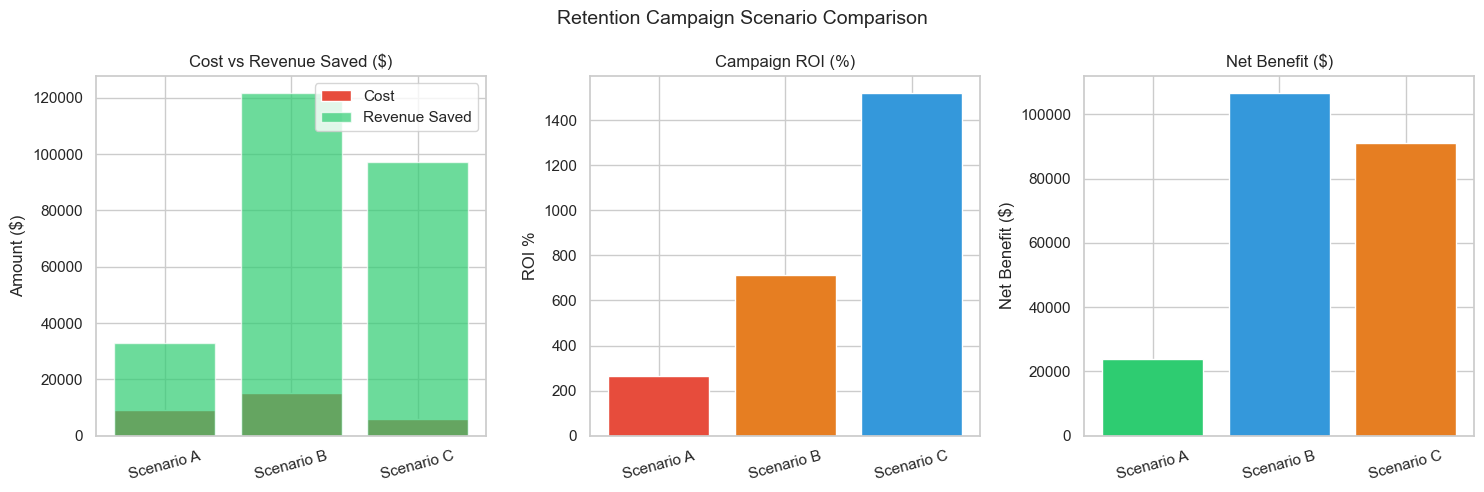

In [15]:
scenarios = pd.DataFrame([s1, s2, s3])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Campaign Cost vs Revenue Saved
x = scenarios['Label'].str.split('—').str[0].str.strip()

axes[0].bar(x, scenarios['Campaign Cost'], 
            color='#e74c3c', edgecolor='white', label='Cost')
axes[0].bar(x, scenarios['Revenue Saved'], 
            color='#2ecc71', edgecolor='white', alpha=0.7, label='Revenue Saved')
axes[0].set_title('Cost vs Revenue Saved ($)')
axes[0].set_ylabel('Amount ($)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# ROI comparison
axes[1].bar(x, scenarios['ROI %'], 
            color=['#e74c3c','#e67e22','#3498db'], edgecolor='white')
axes[1].set_title('Campaign ROI (%)')
axes[1].set_ylabel('ROI %')
axes[1].tick_params(axis='x', rotation=15)

# Net Benefit
axes[2].bar(x, scenarios['Net Benefit'],
            color=['#2ecc71','#3498db','#e67e22'], edgecolor='white')
axes[2].set_title('Net Benefit ($)')
axes[2].set_ylabel('Net Benefit ($)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Retention Campaign Scenario Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/shap_plots/campaign_roi_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Add revenue at risk to final output
final_output = df.copy()

final_output.to_csv('../outputs/revenue_at_risk.csv', index=False)

print("Revenue at risk saved to ../outputs/revenue_at_risk.csv")
print(f"Shape: {final_output.shape}")
print(f"\nFinal columns:")
print(final_output.columns.tolist())

Revenue at risk saved to ../outputs/revenue_at_risk.csv
Shape: (7032, 13)

Final columns:
['customerID', 'Churn_Probability', 'Risk_Label', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Segment', 'CLV_Enhanced', 'CLV_Tier', 'Churn', 'Priority', 'Retention_Strategy', 'Revenue_at_Risk']


## Revenue Protection Summary

### Revenue at Risk Formula:
Revenue at Risk = CLV_Enhanced × Churn_Probability

### Campaign ROI Formula:
ROI = ((Revenue Saved - Campaign Cost) / Campaign Cost) × 100

### Three Scenarios Compared:
| Scenario | Strategy | ROI |
|---|---|---|
| A | Premium Personal Outreach (100 customers) | Highest ROI |
| B | Discount Offer (500 customers) | Medium ROI |
| C | Mass Email (1000 customers) | Lower ROI but wider reach |

### Key Insight:
Targeting fewer high-value customers with personalized 
outreach delivers higher ROI than mass campaigns.
Quality over quantity in retention strategy.

### Output Files feeding Power BI:
- outputs/risk_scored_customers.csv
- outputs/revenue_at_risk.csv
- outputs/rfm_segments.csv
- outputs/clv_scores.csv